In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta 
import numpy as np
import warnings
from financial_forecasting_platform.pipelines.data_ingestion.nodes import download_ohlcv_data

In [2]:
tickers = ["GOOG", "AAPL", "NVDA", "MSFT"]
start_date = "2020-01-01"
end_date = "2025-01-01"
df = download_ohlcv_data(tickers, start_date, end_date)
df.head()


[*********************100%***********************]  4 of 4 completed


Price,Date,Ticker,Open,High,Low,Close,Volume
0,2020-01-02,GOOG,66.491271,67.809150,66.491271,67.770988,28132000
1,2020-01-02,MSFT,150.090248,151.933525,149.664878,151.829544,22622100
2,2020-01-02,NVDA,5.934968,5.963803,5.884505,5.963803,237536000
3,2020-01-02,AAPL,71.344054,72.394086,71.091184,72.333878,135480400
4,2020-01-03,GOOG,66.804002,68.025237,66.689215,67.438408,23728000


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5032 entries, 0 to 5031
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    5032 non-null   datetime64[s]
 1   Ticker  5032 non-null   str          
 2   Open    5032 non-null   float64      
 3   High    5032 non-null   float64      
 4   Low     5032 non-null   float64      
 5   Close   5032 non-null   float64      
 6   Volume  5032 non-null   int64        
dtypes: datetime64[s](1), float64(4), int64(1), str(1)
memory usage: 295.6 KB
None


In [4]:
print(df.describe())

Price                 Date         Open         High          Low  \
count                 5032  5032.000000  5032.000000  5032.000000   
mean   2022-07-01 15:39:46   148.518956   150.166578   146.895892   
min    2020-01-02 00:00:00     4.977162     5.221915     4.494121   
25%    2021-04-01 00:00:00    74.655655    75.415587    73.808623   
50%    2022-06-30 12:00:00   136.874162   138.483038   135.131082   
75%    2023-10-02 00:00:00   195.292455   197.860207   192.964382   
max    2024-12-31 00:00:00   459.774253   461.103469   457.273574   
std                    NaN   103.298654   104.098089   102.419084   

Price        Close        Volume  
count  5032.000000  5.032000e+03  
mean    148.596521  1.483483e+08  
min       4.885131  6.809800e+06  
25%      74.902237  2.493200e+07  
50%     136.710510  4.806105e+07  
75%     195.446033  1.931070e+08  
max     460.325684  1.543911e+09  
std     103.302654  1.998378e+08  


In [5]:
print(df.head())

Price       Date Ticker        Open        High         Low       Close  \
0     2020-01-02   GOOG   66.491271   67.809150   66.491271   67.770988   
1     2020-01-02   MSFT  150.090248  151.933525  149.664878  151.829544   
2     2020-01-02   NVDA    5.934968    5.963803    5.884505    5.963803   
3     2020-01-02   AAPL   71.344054   72.394086   71.091184   72.333878   
4     2020-01-03   GOOG   66.804002   68.025237   66.689215   67.438408   

Price     Volume  
0       28132000  
1       22622100  
2      237536000  
3      135480400  
4       23728000  


In [6]:
print(df["Ticker"].value_counts())

Ticker
GOOG    1258
MSFT    1258
NVDA    1258
AAPL    1258
Name: count, dtype: int64


array([[<Axes: title={'center': 'Open'}>,
        <Axes: title={'center': 'High'}>],
       [<Axes: title={'center': 'Low'}>,
        <Axes: title={'center': 'Close'}>]], dtype=object)

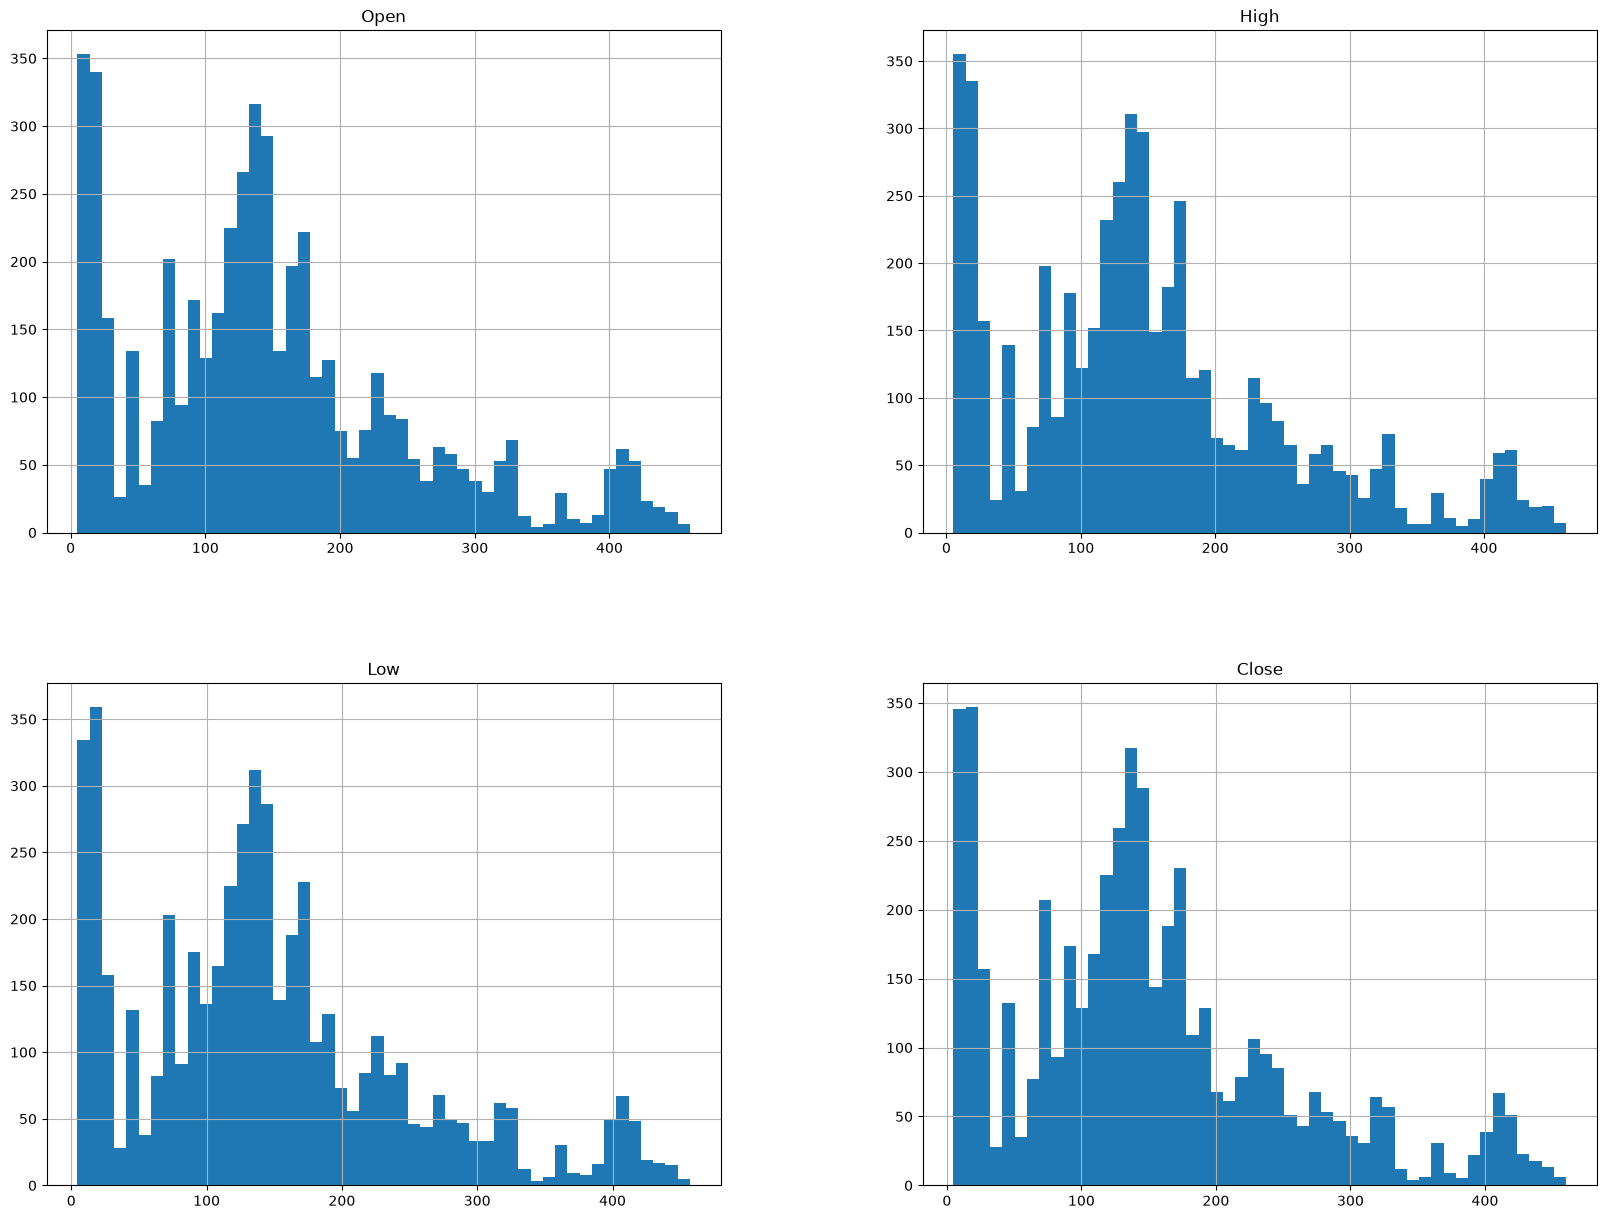

In [7]:
df.iloc[:, [1,2,3,4,5]].hist(bins=50, figsize=(20,15))

In [8]:
print(df.corr(numeric_only = True))

Price       Open      High       Low     Close    Volume
Price                                                   
Open    1.000000  0.999881  0.999865  0.999711 -0.602122
High    0.999881  1.000000  0.999838  0.999861 -0.601977
Low     0.999865  0.999838  1.000000  0.999878 -0.603223
Close   0.999711  0.999861  0.999878  1.000000 -0.602607
Volume -0.602122 -0.601977 -0.603223 -0.602607  1.000000


In [9]:
from financial_forecasting_platform.pipelines.feature_engineering.nodes import feature_engineering, target_variable_engineering
feature_engineered_df = feature_engineering(df)
feature_engineered_df['market_movement'] = target_variable_engineering(df).values
feature_engineered_df['market_movement'].value_counts()
feature_engineered_df.head()

Price,Date,Ticker,Open,High,Low,Close,Volume,return_lag_1,return_lag_5,return_lag_10,...,volume_pct_change,relative_volume_30,volume_sma_20,return_x_volume,drawdown_30,rolling_window_mdd_30,sharpe_30,day_of_week,month,market_movement
0,2020-01-02,GOOG,66.491271,67.809150,66.491271,67.770988,28132000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Thursday,01,0.0
1,2020-01-02,MSFT,150.090248,151.933525,149.664878,151.829544,22622100,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Thursday,01,0.0
2,2020-01-02,NVDA,5.934968,5.963803,5.884505,5.963803,237536000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Thursday,01,0.0
3,2020-01-02,AAPL,71.344054,72.394086,71.091184,72.333878,135480400,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Thursday,01,0.0
4,2020-01-03,GOOG,66.804002,68.025237,66.689215,67.438408,23728000,-0.004907,NaN,NaN,...,-0.156548,NaN,NaN,-7.891472e+06,NaN,NaN,NaN,Friday,01,1.0


array([[<Axes: title={'center': 'Date'}>,
        <Axes: title={'center': 'Open'}>,
        <Axes: title={'center': 'High'}>,
        <Axes: title={'center': 'Low'}>,
        <Axes: title={'center': 'Close'}>,
        <Axes: title={'center': 'Volume'}>,
        <Axes: title={'center': 'return_lag_1'}>],
       [<Axes: title={'center': 'return_lag_5'}>,
        <Axes: title={'center': 'return_lag_10'}>,
        <Axes: title={'center': 'return_lag_20'}>,
        <Axes: title={'center': 'log_return_lag_1'}>,
        <Axes: title={'center': 'SMA_5'}>,
        <Axes: title={'center': 'SMA_20'}>,
        <Axes: title={'center': 'SMA_50'}>],
       [<Axes: title={'center': 'ema_12'}>,
        <Axes: title={'center': 'ema_26'}>,
        <Axes: title={'center': 'close_vs_SMA_20'}>,
        <Axes: title={'center': 'rsi_14'}>,
        <Axes: title={'center': 'momentum_5'}>,
        <Axes: title={'center': 'momentum_20'}>,
        <Axes: title={'center': 'momentum_60'}>],
       [<Axes: title={'ce

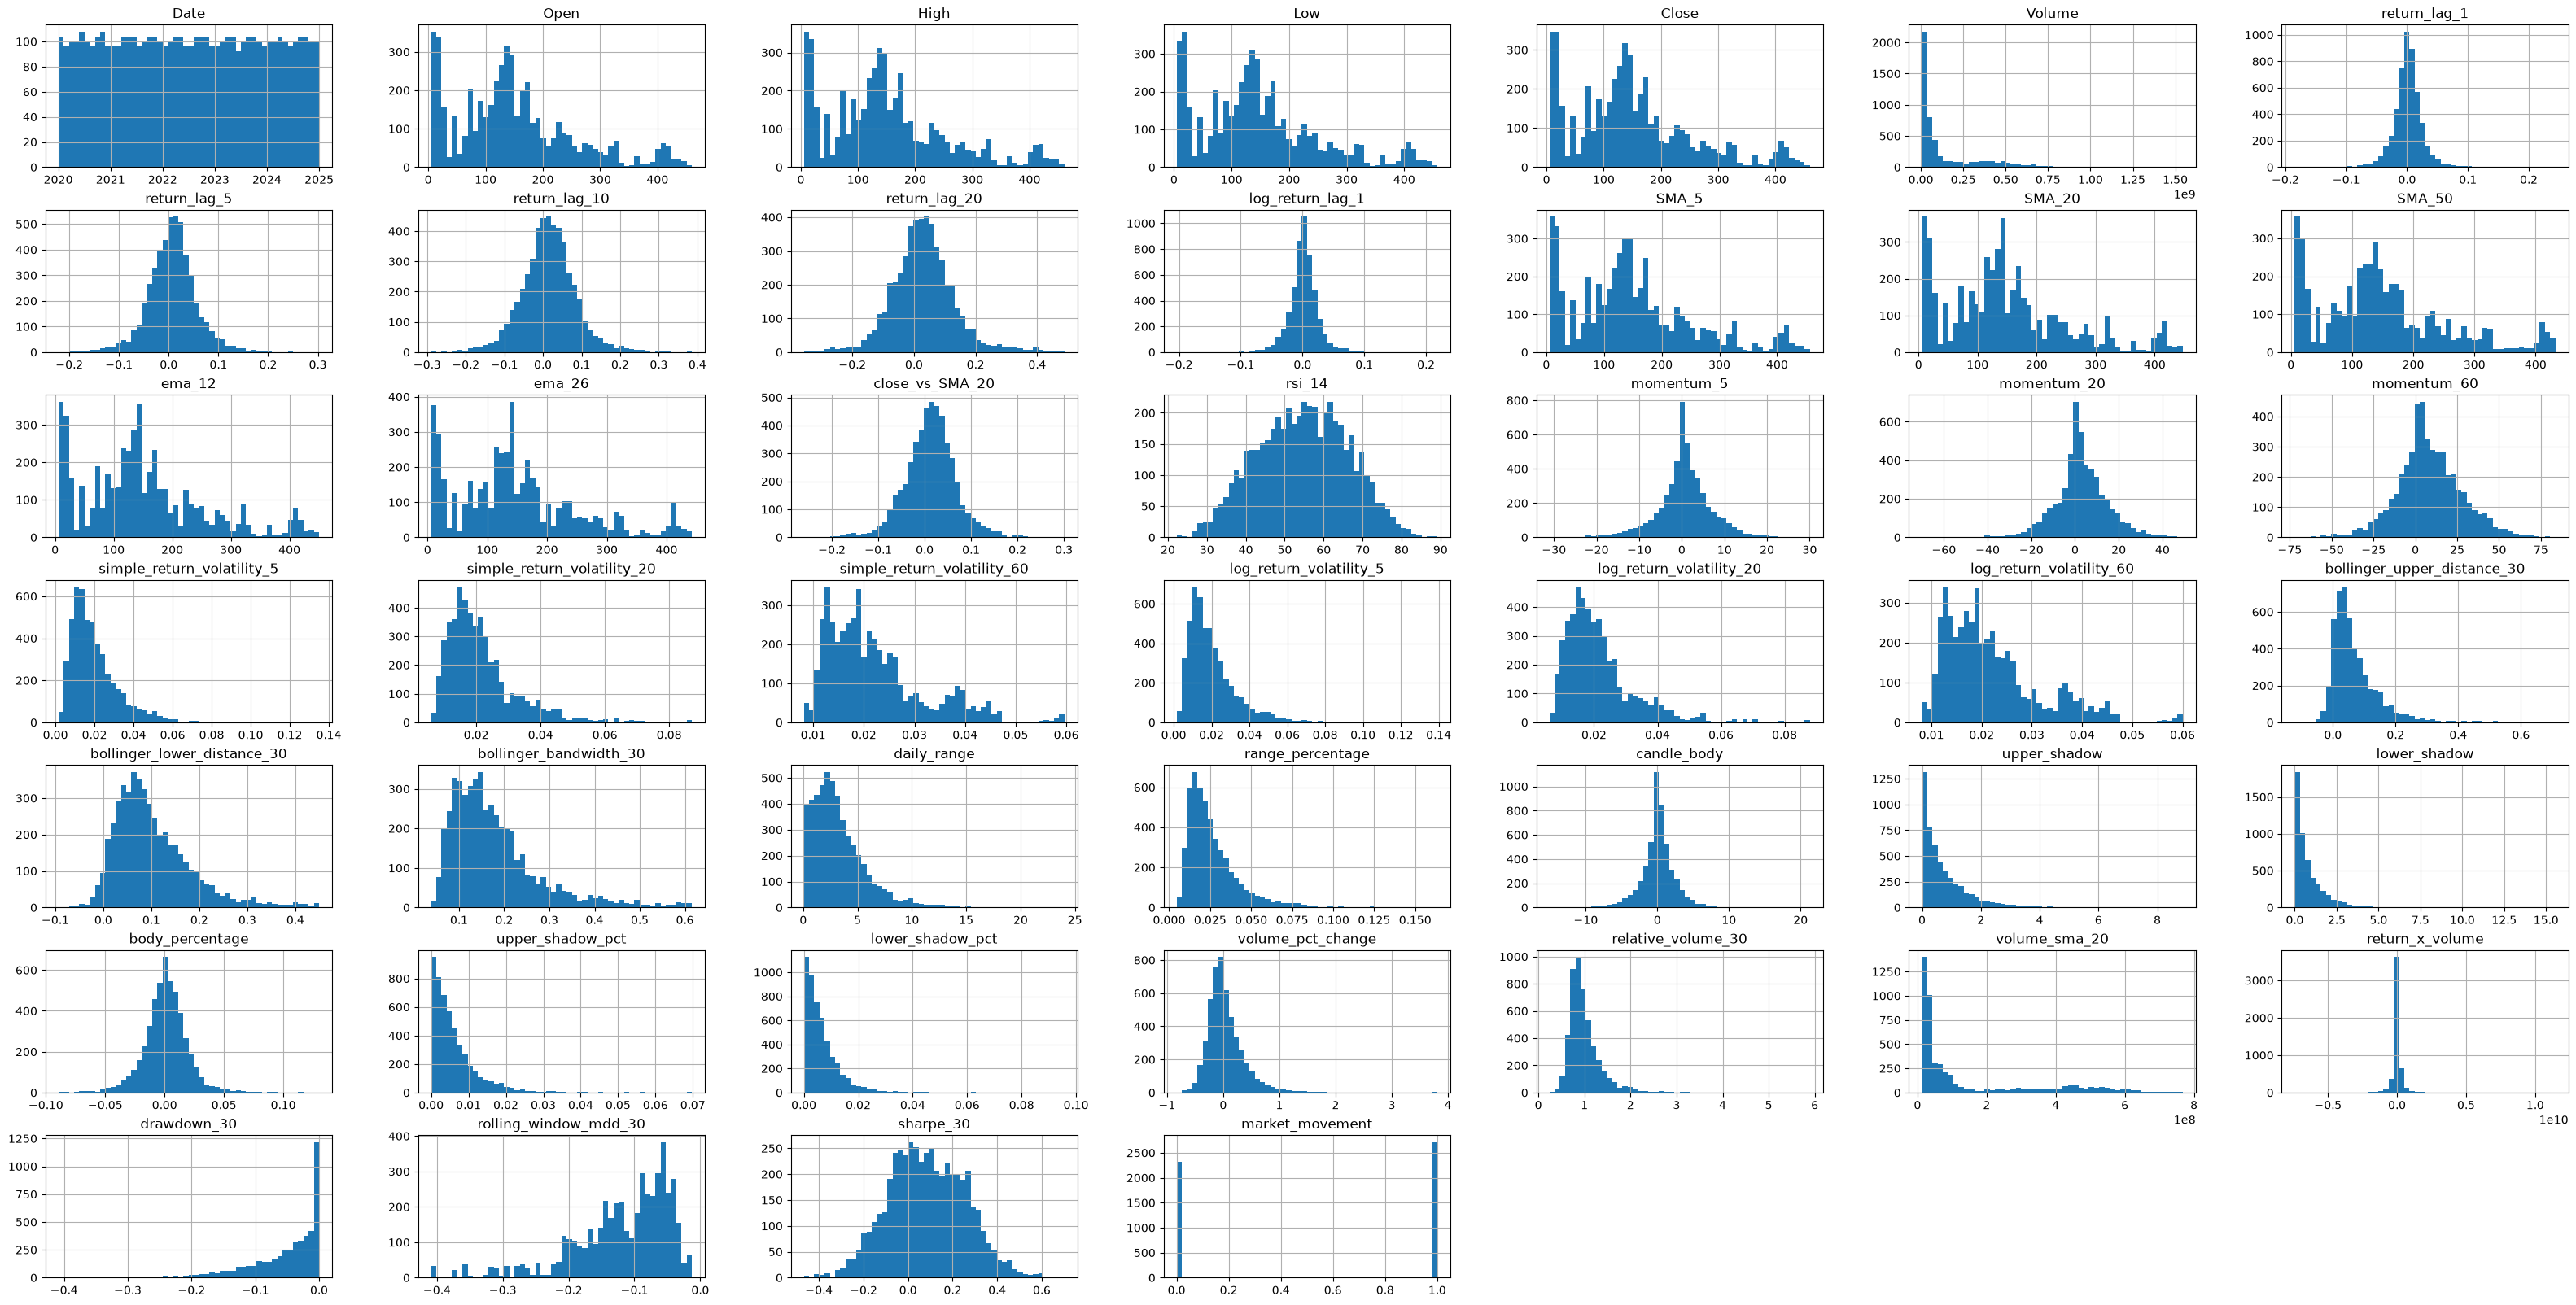

In [10]:
feature_engineered_df.iloc[:].hist(bins=50, figsize=(40,20))

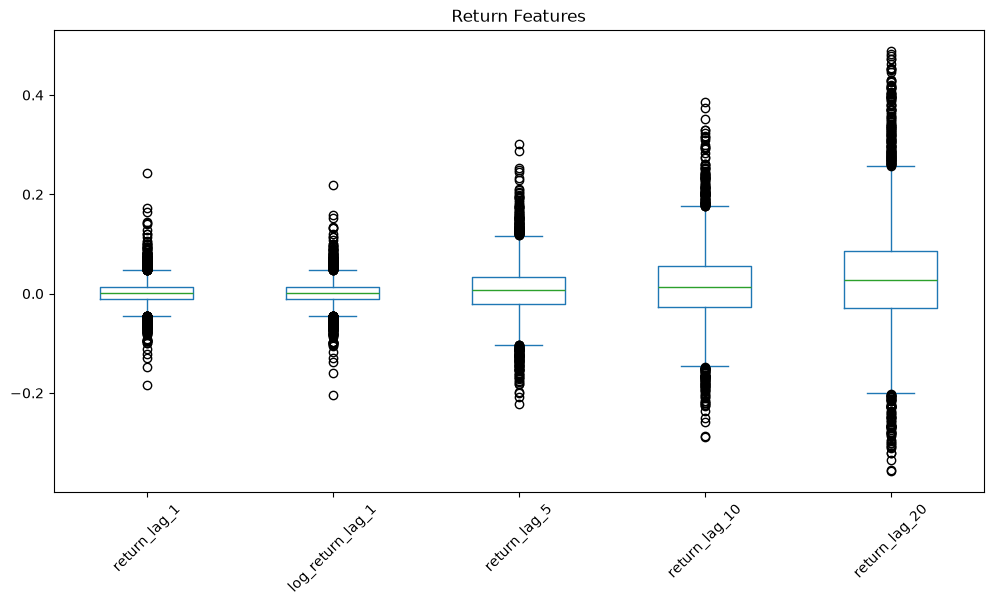

In [11]:
return_features = [
    "return_lag_1",
    "log_return_lag_1",
    "return_lag_5",
    "return_lag_10",
    "return_lag_20"
]

feature_engineered_df[return_features].plot.box(figsize=(12,6))
plt.title("Return Features")
plt.xticks(rotation=45)
plt.show()


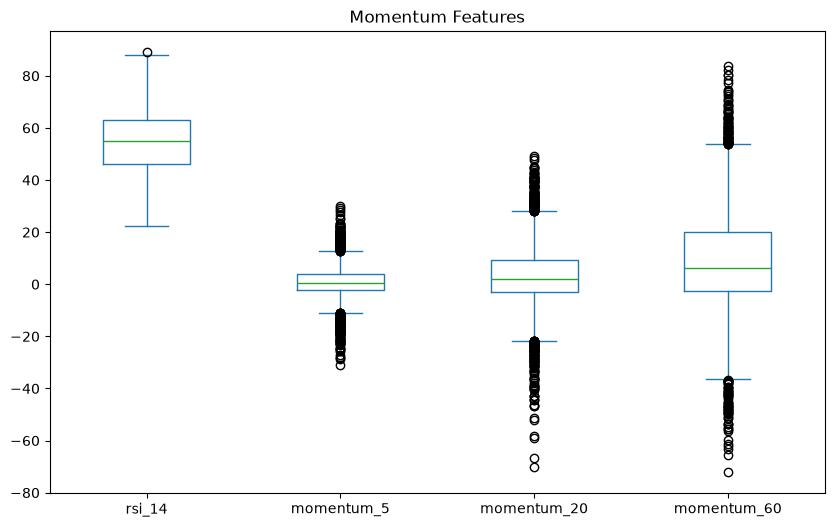

In [12]:
momentum_features = [
    "rsi_14",
    "momentum_5",
    "momentum_20",
    "momentum_60"
]

feature_engineered_df[momentum_features].plot.box(figsize=(10,6))
plt.title("Momentum Features")
plt.show()

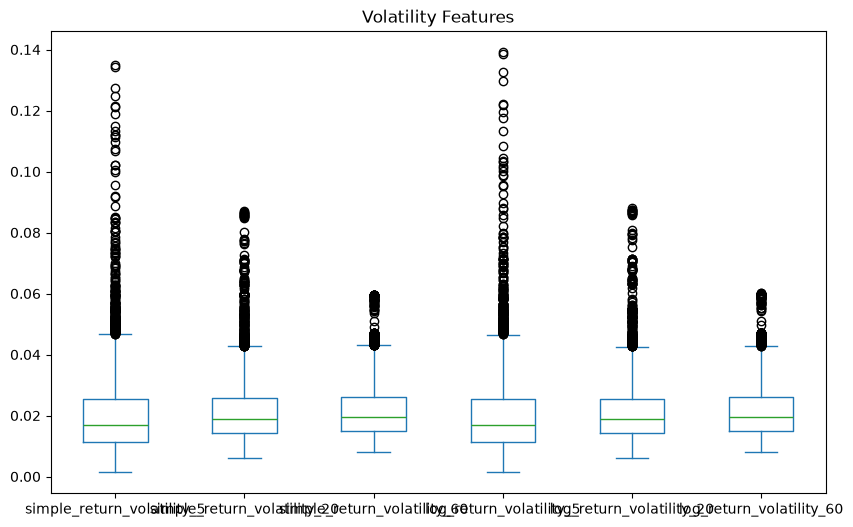

In [13]:
volatility_features = [
    "simple_return_volatility_5",
    "simple_return_volatility_20",
    "simple_return_volatility_60",
    "log_return_volatility_5",
    "log_return_volatility_20",
    "log_return_volatility_60"
]

feature_engineered_df[volatility_features].plot.box(figsize=(10,6))
plt.title("Volatility Features")
plt.show()

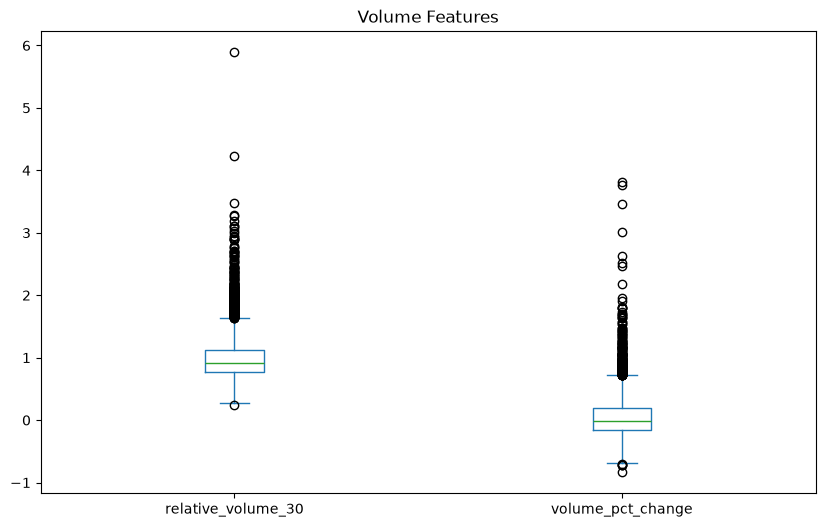

In [14]:
volume_features = [
    "relative_volume_30",
    "volume_pct_change"
]

feature_engineered_df[volume_features].plot.box(figsize=(10,6))
plt.title("Volume Features")
plt.show()

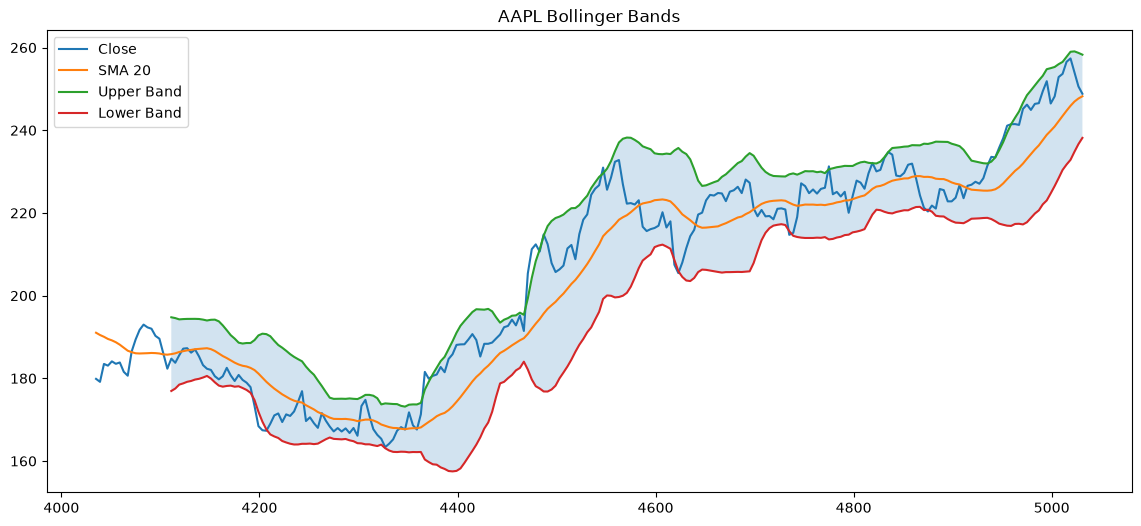

In [15]:
ticker = "AAPL"
window_size = 20

plot_df = feature_engineered_df.copy()
plot_df = plot_df[plot_df["Ticker"] == ticker].tail(250)
plot_df.sort_values("Date", inplace=True)

sma = plot_df.groupby("Ticker")["Close"].transform(lambda x: x.rolling(window=window_size, min_periods=window_size).mean())
standard_deviation = plot_df.groupby("Ticker")["Close"].transform(lambda x: x.rolling(window=window_size, min_periods=window_size).std())
upper_band = sma + 2*standard_deviation
lower_band = sma - 2*standard_deviation

plt.figure(figsize=(14,6))

plt.plot(plot_df.index, plot_df["Close"], label="Close")
plt.plot(plot_df.index, plot_df["SMA_20"], label="SMA 20")
plt.plot(plot_df.index, upper_band, label="Upper Band")
plt.plot(plot_df.index, lower_band, label="Lower Band")

plt.fill_between(
    plot_df.index,
    lower_band,
    upper_band,
    alpha=0.2
)

plt.title(f"{ticker} Bollinger Bands")
plt.legend()
plt.show()

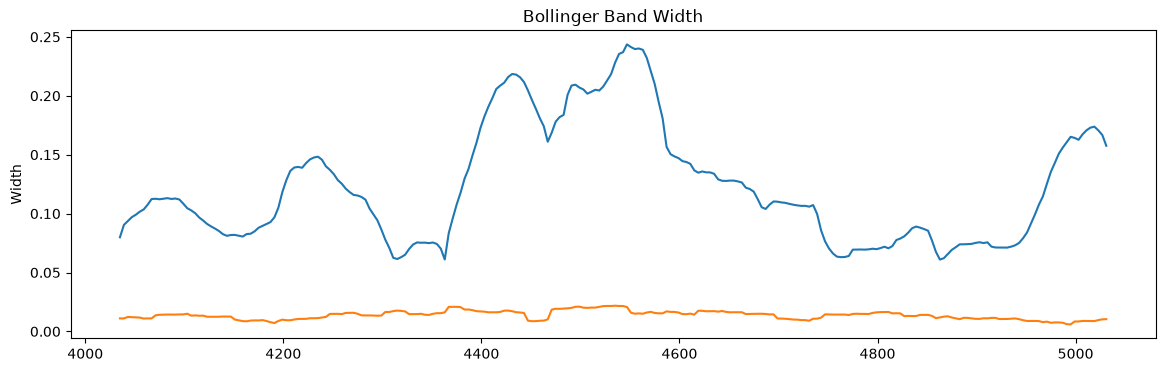

In [16]:
plt.figure(figsize=(14,4))

plt.plot(plot_df.index, plot_df["bollinger_bandwidth_30"])
plt.plot(plot_df.index, plot_df["simple_return_volatility_20"])

plt.title("Bollinger Band Width")
plt.ylabel("Width")
plt.show()

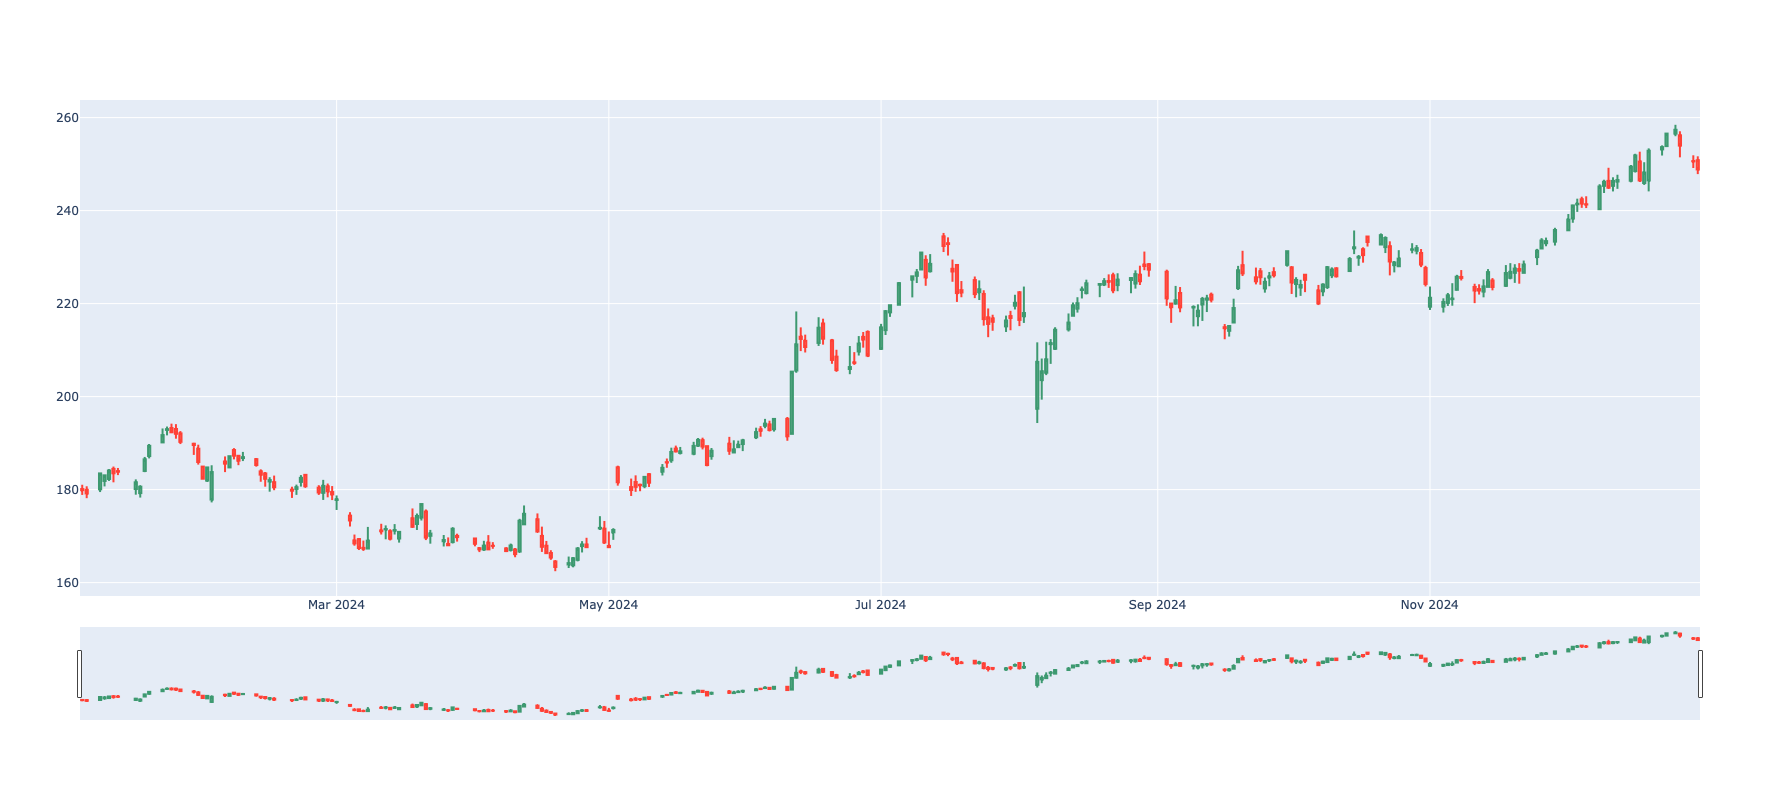

In [23]:
# !pip install plotly
import plotly.graph_objects as go


fig = go.Figure(data=[go.Candlestick(x=plot_df['Date'],
                open=plot_df['Open'],
                high=plot_df['High'],
                low=plot_df['Low'],
                close=plot_df['Close'])])
fig.update_layout(
    width=1700, height=800)

fig.show()